
This pipeline is not a standard binary classification exercise; it is an Asymmetric Financial Risk Minimizer. In the German Credit dataset, the cost of a False Negative (approving a defaulter) is geometrically higher (5×) than the cost of a False Positive (rejecting a good customer). Standard machine learning pipelines optimize symmetric statistical proxies (like Accuracy, MSE, or F1​-score). This architecture intentionally bridges the gap between pure statistical probability, complex meta-heuristic optimization, and human-interpretable fuzzy logic, strictly bound by the financial reality of the deployment domain.

Component 1: Cryptographic Data Isolation

The What: The raw data is ingested and immediately bifurcated using a strict 80/20 Stratified split.
The Why: Leakage Prevention. Absolutely no spatial conditioning (scaling), synthetic oversampling, or encoding is permitted prior to this split. Performing global transformations beforehand allows the statistical moments (mean, variance) of the Test Set to bleed into the Training Set, hallucinating predictive performance and destroying the integrity of the final financial evaluation.

Component 2: The Nested Synthesis Engine (Base Estimators)

The What: We construct an ensemble of three distinct inductive biases: a Random Forest (Bagging/Decision Trees), a Support Vector Machine (Maximum Margin Geometry), and a Multilayer Perceptron (Deep Function Approximator). These are trained using a mathematically rigorous Nested Cross-Validation pipeline.
The Why: * Robust Scaling: Credit amounts possess massive outliers. Using standard L2 moments (μ,σ) would compress the vector space. We use Order Statistics (Median/IQR) to preserve the Euclidean topology for downstream distance calculations.

    SMOTENC & Identity Contracts: We cannot geometrically interpolate one-hot encoded (Boolean) vectors. We scale the continuous features, apply SMOTENC to safely synthesize raw nominal categories, and then apply orthogonal expansion (OneHotEncoder). An Identity Matrix transformer (StandardScaler(with_mean=False, with_std=False)) acts as a software engineering bridge to safely type-cast the mixed-data output to float64 without altering the math.

    Probability Calibration: For Swarm Optimization to work, base models must output true probabilities. Random Forests are chronically underconfident (variance/bagging compression), and SVMs are chronically overconfident (hard margins). We wrap them in Isotonic Regression and Sigmoid (Platt) Scaling, respectively, to guarantee a reliable probability simplex.

    Nested HPO: Hyperparameter bounds are explicitly aligned with the physical limits of the data (e.g., constraining tree depth based on Ntrain​). By nesting the stochastic Monte Carlo search (RandomizedSearchCV) inside the K-Fold loop, we generate Out-of-Fold (OOF) predictions that are completely blind to their own validation data.

Component 3: The Convex Mathematical Floor (Quadratic Programming)

The What: We establish a definitive mathematical baseline by solving for the optimal ensemble weights that strictly minimize Mean Squared Error (MSE) using an SLSQP active-set solver.
The Why: MSE is a strictly convex function. By representing it algebraically as 21​wTQw+cTw (where Q is the Positive Semi-Definite Gram matrix), we mathematically guarantee the discovery of the absolute global minimum. This provides the absolute accuracy floor that our stochastic heuristic (the Swarm) must attempt to match.

Component 4: Swarm Intelligence (Ant Colony Optimization)

The What: We deploy Continuous Ant Colony Optimization (ACO_R) to discover optimal ensemble weights. The ants sample coordinates from Gaussian distributions centered around an archive of historical elite solutions.
The Why: While QP solves convex MSE perfectly, it fails on non-differentiable step-functions (like our absolute Cost Matrix). ACO is a gradient-free meta-heuristic capable of navigating arbitrary, non-convex manifolds. To ensure the ants search valid probability spaces, their unconstrained real-number coordinates (RN) are mathematically projected onto the probability simplex (∑wi​=1) via the Softmax function.

Component 5: Asymmetric Risk Calibration

The What: We discard symmetric decision thresholds (0.5) and harmonic proxies (F1​-score). We sweep the exact empirical probability boundaries (the CDF step-function) of an isolated Calibration hold-out set to find the threshold (t∗) that explicitly minimizes the linear cost function: J(t)=5⋅FN(t)+1⋅FP(t).
The Why: The Pareto Frontier. To minimize financial ruin, the algorithm must actively sacrifice Precision to capture Recall. By evaluating the absolute dollar-cost strictly on P_calib (avoiding the P_opt data the Swarm just memorized), we discover an asymmetric boundary that safely generalizes to unseen data.

Component 6: Linguistic Translation (Neuro-Fuzzy ANFIS)

The What: We implement a 1-Dimensional Takagi-Sugeno Adaptive Neuro-Fuzzy Inference System in PyTorch. It maps the continuous statistical probability output by the Swarm into human-readable linguistic rules (Low, Medium, High Risk).
The Why: * Sigmoid Reparameterization: Fuzzy logic requires parameters to remain strictly bounded (probabilities ∈[0,1], widths >0). Standard clamping creates a "gradient guillotine" that traps parameters during Adam optimization. We map unconstrained tensors through scaled sigmoid functions, allowing the optimizer to move freely in infinite space while analytically guaranteeing topological boundaries.

    Frozen Expert Premises: To ensure the fuzzy logic aligns with our financial reality, we initialize the Gaussian premise centers based on the asymmetric threshold (t∗). We then strictly freeze (requires_grad=False) these centers. This prevents the symmetric MSE optimizer from destroying the asymmetric financial logic during training, forcing it to only optimize the linear consequents.

Component 7: The Crucible (Domain Generalization)

The What: The cryptographically isolated Test Set is passed through the frozen pipeline.
The Why: This is the ultimate proof of architecture. It validates that the rigorous scaling, synthetic generation, bi-level optimization, and asymmetric calibration successfully extracted the maximum possible predictive signal from the dataset up to its irreducible Bayes Error, achieving financial minimization without succumbing to spatial leakage or threshold overfitting.


This notebook implements an advanced, financially-aligned machine learning architecture. It is designed to solve a fundamental flaw in standard classification pipelines: the assumption of symmetric risk. In the context of the German Credit dataset, approving a bad loan (False Negative) is mathematically five times more destructive than rejecting a good customer (False Positive).

Every cell in this notebook is engineered to explicitly minimize that asymmetric financial reality, bridging the gap between rigorous statistical isolation, meta-heuristic optimization, and fuzzy linguistic logic.

Below is the chronological breakdown of the pipeline's execution.
Block 1: Data Ingestion & Cryptographic Splitting

    The Action: We load the German Credit dataset, explicitly map the "Bad" credit class to 1 (ensuring all downstream probabilities represent the risk of default), and execute a strict 80/20 Stratified Split.

    The Architectural Why: This establishes the fundamental data vault. Absolutely no preprocessing (scaling, encoding, or oversampling) is permitted before this cell. Performing geometric transformations beforehand allows the statistical variance of the Test Set to bleed into the Training Set. By splitting first, we guarantee a mathematically pristine, unseen Test Set for the final evaluation.

Block 2: Leakage-Free OOF Generation via Nested CV

    The Action: We construct three distinct base estimators (Random Forest, SVM, MLP). They are wrapped in a strictly ordered ImbPipeline that applies Robust Scaling, synthesizes minority profiles via SMOTENC, and calibrates their probability outputs (Isotonic/Sigmoid). These pipelines are optimized using a Nested K-Fold Cross-Validation loop.

    The Architectural Why: This is the heaviest computational cell. We use RobustScaler because standard deviation is destroyed by extreme credit amount outliers. We use SMOTENC because standard SMOTE cannot mathematically interpolate categorical variables. We use Nested CV because we need to generate Out-of-Fold (OOF) probabilities for the Swarm to learn from. If the base models generate these probabilities on data they trained on, the Swarm will overfit to their hallucinations. Nested CV guarantees zero target leakage.

Block 3: Mathematical Optimization (The QP Benchmark)

    The Action: We take 75% of the OOF probabilities generated in Block 2 and use Sequential Least SQuares Programming (SLSQP) to find the exact ensemble weights that minimize Mean Squared Error (MSE). We strictly constrain the solver to the probability simplex (weights must be ≥0 and sum to 1.0).

    The Architectural Why: Before unleashing a complex AI Swarm, we must establish a mathematical floor. Because MSE is a strictly convex function, Quadratic Programming (QP) mathematically guarantees finding the absolute global minimum. This provides the deterministic benchmark that our Swarm must attempt to match.

Block 4: Swarm Intelligence (Continuous ACO)

    The Action: We deploy Ant Colony Optimization for Continuous Domains (ACO_R). A swarm of digital ants searches for optimal ensemble weights by sampling from Gaussian distributions centered around an archive of elite historical solutions.

    The Architectural Why: While QP perfectly solves convex equations like MSE, it fails catastrophically on non-differentiable or non-convex surfaces (like our discrete 5:1 business cost matrix). We deploy the ACO here to prove it can match the QP benchmark, establishing the gradient-free heuristic engine that can later be adapted for arbitrary, complex financial manifolds.

Block 5: Asymmetric Risk Threshold Calibration

    The Action: We discard the default 0.5 decision threshold and the symmetric F1​-score. Instead, we evaluate the absolute linear cost function (Cost=5⋅FN+1⋅FP) across the exact empirical probability boundaries of a 25% isolated Calibration Set.

    The Architectural Why: This is the critical financial pivot. To minimize ruin, the algorithm must actively sacrifice Precision to capture Recall. By sweeping the exact CDF step-function on unseen calibration data, we discover the exact, cost-optimal boundary (t∗) for each ensemble without grid-miss errors or optimization-set overfitting.

Block 6: Soft Computing (Neuro-Fuzzy ANFIS)

    The Action: We build a 1-Dimensional Takagi-Sugeno ANFIS in PyTorch. It maps the Swarm's raw statistical probability into three linguistic Gaussian rules (Low, Medium, High Risk). We explicitly anchor and freeze the rule centers to the asymmetric threshold (t∗) discovered in Block 5, allowing the Adam optimizer to only train the linear outputs.

    The Architectural Why: Bank officers do not think in floating-point probabilities; they think in linguistic concepts. Standard neural networks suffer from the "gradient guillotine" when parameters are bounded, so we use Sigmoid Reparameterization to safely train the fuzzy logic in unconstrained space. By freezing the premises, we prevent the symmetric MSE optimizer from destroying the asymmetric financial boundary, perfectly aligning the fuzzy logic with our risk calculus.

Block 7: The Crucible (Domain Generalization on Test Set)

    The Action: The cryptographically isolated 20% Test Set from Block 1 is finally passed through the frozen pipelines, aggregated by the Swarm weights, thresholded by t∗, and evaluated for absolute expected cost.

    The Architectural Why: This is the final proof of architecture. If the cost drops and the Domain Validation aligns (meaning the ANFIS correctly flags ensemble rejections as risky), it proves that our rigorous constraints—leakage prevention, robust scaling, and decoupled calibration—successfully solved the Pareto frontier of the dataset up to its irreducible Bayes Error.

In [ ]:
# ENSEMBLE CREDIT RISK ASSESSMENT: ML + ACO + ANFIS + QP BENCHMARK
#
# ARCHITECTURAL NOTE — ANFIS:
# The ANFIS component implements Option A (Confidence Calibration). Rather than
# causing rule explosion via 20 raw features, it takes the ACO-optimized
# continuous probability as a univariate input and acts as a non-linear
# neuro-fuzzy calibrator mapping statistical confidence to linguistic rules.
#
# ARCHITECTURAL NOTE — ACO SIMPLEX MAPPING:
# Unconstrained ACO coordinates are mapped to the probability simplex via
# softmax. This guarantees differentiability and sum-to-one, but cannot
# produce weights of exactly 0.0 or 1.0 (only asymptotic approach).
# For this 3-model ensemble the approximation error is negligible. If exact
# sparsity (hard model elimination) were required, Euclidean projection onto
# the unit simplex would be the correct replacement.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
#from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
#from imblearn.over_sampling import SMOTE
import warnings
from sklearn.exceptions import ConvergenceWarning
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             precision_recall_curve)

In [ ]:
# [Block 1] Data Ingestion & Cryptographic Splitting
#
# ARCHITECTURAL INTENT:
# This block establishes the fundamental data vault of the pipeline. It ingests
# the raw German Credit dataset and immediately bifurcates it into a Training/Optimization
# environment (80%) and a cryptographically isolated Test environment (20%).
#
# STRICT LEAKAGE PREVENTION:
# Absolutely no spatial conditioning (scaling), imputation, encoding, or
# synthetic resampling (SMOTENC) is permitted before this split. Performing
# any geometric transformations prior to this step allows the statistical moments
# (mean, variance) of the Test Set to bleed into the Training Set, permanently
# invalidating the final financial cost calculations.

print("--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---")

# 1. Ingestion
# Fetch the German Credit dataset ('credit-g') from the OpenML repository.
# as_frame=True guarantees that the dataset is loaded as a Pandas DataFrame.
# This preserves the structural metadata (dtypes) separating numerical columns
# from categorical strings, which is a strict dependency for SMOTENC in Block 2.
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data

# 2. Target Variable Topological Mapping
# The raw dataset defines targets as 'good' and 'bad' credit risks.
# We explicitly map 'bad' -> 1 (Positive Class) and 'good' -> 0 (Negative Class).
#
# MATHEMATICAL ALIGNMENT:
# This specific mapping is non-negotiable. Our asymmetric cost function
# (5 * FN + 1 * FP) relies on the algorithm detecting the "Bad" class. By mapping
# 'bad' to 1, all probability outputs in the pipeline fundamentally represent
# P(Default). A False Negative now correctly represents predicting 0 (Good)
# when the reality is 1 (Bad).
y = data.target.map({'good': 0, 'bad': 1}).values.astype(int)

# 3. Stratified Bifurcation
# We execute a strict 80/20 train-test split.
#
# STRATIFICATION MANDATE:
# The German Credit dataset has a heavy class imbalance (70% Good, 30% Bad).
# We explicitly pass `stratify=y`. Without this, a random split could easily
# produce a Test Set with an 85/15 ratio. If the Test prior diverges from the
# Training prior, the Cost-Optimal threshold (t*) calibrated in Block 5 will
# mathematically fail to generalize to Block 8.
X_train, X_test, y_train_array, y_test_array = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42   # Deterministic seed for reproducible matrix geometries
)

print(f"Data securely partitioned. Train: {X_train.shape}, Test: {X_test.shape}")

--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---
Data securely partitioned. Train: (800, 20), Test: (200, 20)


In [ ]:
# [Block 2] OOF Generation via Nested CV & Mixed-Data Synthesis
#
# ARCHITECTURAL NOTE — HPO SPARSITY:
# Due to the cubic complexity of the inner loops (SMOTENC k-NN + Calibrator CV),
# n_iter=15 is a strict compute budget constraint. Coverage is extremely sparse
# (~0.02% of the ~72k RF combinations). This is a pragmatic random Monte Carlo
# probe, not an exhaustive manifold search.
#
# ARCHITECTURAL NOTE — MLP EARLY STOPPING HAZARD:
# early_stopping=True splits 10% of the active pipeline data for validation.
# Because this occurs downstream of SMOTENC, this 10% holdout contains synthetic
# distributions. The MLP stopping criterion is therefore partially evaluated on
# non-natural data geometry. The outer K-Fold provides the ultimate generalization guard.

print("\n--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---")

# ------------------------------------------------------------------------------
# 1. DEFINE COLUMN TOPOLOGIES
# SMOTENC requires strict identification of nominal vs. continuous features.
# Continuous features use Euclidean distance; nominal features use a
# median-standard-deviation penalty metric.
# ------------------------------------------------------------------------------
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
cat_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

# ------------------------------------------------------------------------------
# 2. PREPROCESSING STAGE 1 (SPATIAL CONDITIONING)
# Standard deviation has a breakdown point of 0. We use RobustScaler (Median/IQR,
# 25% breakdown point) so extreme credit amounts do not warp the metric space
# and destroy the geometric fidelity of the downstream k-NN search.
# ------------------------------------------------------------------------------
prep_stage_1 = ColumnTransformer(transformers=[
    ('num', RobustScaler(), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

# ------------------------------------------------------------------------------
# 3. SYNTHESIS STAGE (SMOTENC)
# Synthesizes new minority points to achieve a 1:1 prior distribution.
#k_neighbors=5 explicitly defined to manage the Curse of Dimensionality.
# ------------------------------------------------------------------------------
smote_nc = SMOTENC(categorical_features=cat_indices, k_neighbors=5, random_state=42)

# ------------------------------------------------------------------------------
# 4. PREPROCESSING STAGE 2 (IDENTITY CAST & ORTHOGONAL EXPANSION)
# The StandardScaler acts as a Software Engineering Identity Matrix (X - 0 / 1).
# It mathematically alters nothing, but forces scikit-learn's internal check_array() to physically type-cast the mixed SMOTE outputs into strict float64 memory blocks,
# preventing Object dtype crashes in downstream tensor operations.
# ------------------------------------------------------------------------------
prep_stage_2 = ColumnTransformer(transformers=[
    ('num_pass', StandardScaler(with_mean=False, with_std=False), list(range(len(numerical_cols)))),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), cat_indices)
])

# ------------------------------------------------------------------------------
# 5. CORE ESTIMATORS & PROBABILITY CALIBRATION
# Models must output true probability simplexes [0,1] for downstream Swarm logic.
# - RF: Isotonic regression corrects characteristic underconfidence (bagging variance).
# - SVM: Sigmoid (Platt) corrects characteristic overconfidence (hard margins).
# - MLP: Sigmoid is a conservative choice; natively well-calibrated softmax outputs
#   risk being over-corrected by isotonic step-functions on synthetic noise.
# ------------------------------------------------------------------------------
rf_base = RandomForestClassifier(random_state=42)
rf_calibrated = CalibratedClassifierCV(rf_base, method='isotonic', cv=6)

svm_base = SVC(kernel='rbf', random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_base, method='sigmoid', cv=6)

mlp_base = MLPClassifier(
    solver='adam', max_iter=2000, early_stopping=True, n_iter_no_change=18, random_state=42
)
mlp_calibrated = CalibratedClassifierCV(mlp_base, method='sigmoid', cv=6)

# ------------------------------------------------------------------------------
# 6. ASSEMBLE THE MASTER PIPELINES (IMBLEARN CONTRACT)
# Wrapping everything in ImbPipeline guarantees strict temporal execution:
# .fit() executes Stages 1 -> 2 -> 3 -> 4.
# .predict_proba() executes Stages 1 -> 3 -> 4 (BYPASSING SMOTE).
# ------------------------------------------------------------------------------
base_models = {
    'Random_Forest': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', rf_calibrated)
    ]),
    'SVM': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', svm_calibrated)
    ]),
    'MLP': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', mlp_calibrated)
    ])
}

# ------------------------------------------------------------------------------
# 7. HPO SEARCH MANIFOLDS (PRIORS)
# We map the continuous and discrete geometries for Monte Carlo sampling.
# Note the double-underscore `__` routing to bypass the Calibration wrapper.
# ------------------------------------------------------------------------------
param_distributions = {
    'Random_Forest': {
        'clf__estimator__n_estimators': randint(100, 400),
        # Strict bound: N_train=896 means max binary depth is ~log2(896)=9.8.
        # Range [4, 12] forces the constraint to actually bind.
        'clf__estimator__max_depth': randint(4, 12),
        # Structural Risk Minimization: Floor of 5 guarantees terminal nodes
        # compute empirical probabilities, preventing n=1 Dirac-delta memorization.
        'clf__estimator__min_samples_leaf': randint(5, 15),
        'clf__estimator__max_features': uniform(0.1, 0.5)
    },
    'SVM': {
        # loguniform ensures 10^-3 to 10^-2 gets the same search budget as 10^1 to 10^2
        'clf__estimator__C': loguniform(1e-3, 1e2),
        'clf__estimator__gamma': loguniform(1e-4, 1e0)
    },
    'MLP': {
        'clf__estimator__alpha': loguniform(1e-5, 1e-1),
        'clf__estimator__learning_rate_init': loguniform(5e-4, 1e-2),
        'clf__estimator__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32)]
    }
}

# ------------------------------------------------------------------------------
# 8. NESTED CROSS-VALIDATION (BI-LEVEL OPTIMIZATION)
# Outer Loop (K=5): Generates completely unbiased Out-of-Fold predictions.
# Inner Loop (CV=3): Optimizes hyperparameters exclusively on the training fold.
# ------------------------------------------------------------------------------
K       = 6
skf     = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

tuned_base_models = {}
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for i, (name, model_pipeline) in enumerate(base_models.items()):
    print(f"\nInitiating Stochastic HPO & OOF Generation for {name}...")
    oof_preds = np.zeros(N_train)

    # Layer 4: The HPO Engine
    search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_distributions[name],
        n_iter=18,
        cv=6,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=2  # Prevents silent execution during extreme computational loads
    )

    # Layer 5: Outer CV Loop
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_array)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train_array[train_idx]
        X_fold_val   = X_train.iloc[val_idx]

        # Fits HPO, applies SMOTE, Calibrates, and trains Core Estimator on inner data
        search.fit(X_fold_train, y_fold_train)

        # Predicts on untouched outer validation data (SMOTE is bypassed here)
        oof_preds[val_idx] = search.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds

    # Final Deployment Retune: Lock in optimal parameters on the full 100% training mass
    print(f"  Retuning {name} on 100% Training Data...")
    final_search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_distributions[name],
        n_iter=18, cv=6, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    final_search.fit(X_train, y_train_array)

    tuned_base_models[name] = final_search.best_estimator_
    print(f"  {name:20s} - Final OOF ROC-AUC: {roc_auc_score(y_train_array, oof_preds):.4f}")

base_models = tuned_base_models

# ------------------------------------------------------------------------------
# 9. OOF BIFURCATION
# We strictly decouple the Swarm Optimization set from the Threshold Calibration set.
# This prevents the final t* from overfitting to the same probability surface
# that the ACO utilized to shape the ensemble weights.
# ------------------------------------------------------------------------------
P_opt, P_calib, y_opt, y_calib = train_test_split(
    oof_P_train, y_train_array,
    test_size=0.25, stratify=y_train_array, random_state=42
)
y_opt_float = y_opt.astype(float)


--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---

Initiating Stochastic HPO & OOF Generation for Random_Forest...
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
  Retuning Random_Forest on 100% Training Data...
  Random_Forest        - Final OOF ROC-AUC: 0.7755

Initiating Stochastic HPO & OOF Generation for SVM...
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates

In [ ]:
# [Block 3] Mathematical Optimization (Convex QP Benchmark)
#
# ARCHITECTURAL INTENT:
# Before deploying a stochastic heuristic like Ant Colony Optimization (ACO),
# we must establish a deterministic mathematical benchmark. Because Mean Squared
# Error (MSE) is a strictly convex function, finding the optimal ensemble weights
# subject to linear constraints is a Quadratic Programming (QP) problem.
# This block calculates the mathematically guaranteed global minimum of the MSE
# loss surface, providing the absolute floor that the ACO must attempt to match.
#
# DATA ISOLATION (THE P_OPT MANIFOLD):
# Notice that we are strictly utilizing `P_opt` and `y_opt_float` (75% of the OOF).
# We are mathematically forbidden from showing the solver `P_calib` (the 25% holdout)
# because `P_calib` must remain pristine for the asymmetric threshold calibration
# in Block 5.

print("\n--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---")

# ------------------------------------------------------------------------------
# 1. THE LINEAR ALGEBRA DERIVATION (MSE to QP Form)
# We want to find a weight vector `w` that minimizes the MSE: || Pw - y ||^2
#
# Expanding the L2 Norm:
# L(w) = (Pw - y)^T (Pw - y)
# L(w) = w^T P^T P w - 2 y^T P w + y^T y
#
# Since `y^T y` is a constant with respect to `w`, we drop it.
# The standard form for a Quadratic Program is: min( 0.5 * w^T Q w + c^T w )
#
# To match the standard form, we multiply our expansion by 2/2:
# Q = 2 * P^T P
# c = -2 * P^T y
# ------------------------------------------------------------------------------
Q = 2 * P_opt.T @ P_opt
c = -2 * (P_opt.T @ y_opt_float)

def qp_objective(w, Q, c):
    """
    Evaluates the standard QP objective function.
    Because Q is a Gram matrix (P^T P), it is Positive Semi-Definite (PSD).
    This mathematically guarantees that the loss surface is a convex bowl
    with exactly one global minimum.
    """
    return 0.5 * w @ Q @ w + c @ w

# ------------------------------------------------------------------------------
# 2. THE TOPOLOGICAL CONSTRAINTS (The Probability Simplex)
# If we minimize MSE without constraints, the weights could be negative, or sum to 5.0,
# producing predictions outside the [0, 1] probability space.
# We must force the solution to remain on the standard (K-1) probability simplex.
# ------------------------------------------------------------------------------
# Equality Constraint: The sum of all weights must exactly equal 1.0
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

# Boundary Constraints: No single weight can be negative (no short-selling models),
# and no weight can exceed 1.0.
bounds      = tuple((0.0, 1.0) for _ in range(P_opt.shape[1]))

# Initialize the solver at the geometric center of the simplex (Equal Average)
w_init      = np.ones(P_opt.shape[1]) / P_opt.shape[1]

# ------------------------------------------------------------------------------
# 3. SLSQP EXECUTION (Sequential Least SQuares Programming)
# We deploy the SLSQP solver because it natively handles non-linear optimization
# with strict equality bounds. We tighten the function tolerance (ftol) to 1e-9
# to force the algorithm to search the absolute bottom of the convex basin.
# ------------------------------------------------------------------------------
result = minimize(
    fun=qp_objective,
    x0=w_init,
    args=(Q, c),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9}
)

# Architectural Safeguard: Never blindly consume optimization results.
# If the Hessian matrix becomes ill-conditioned, SLSQP will fail silently.
assert result.success, f"QP Solver encountered a mathematical singularity: {result.message}"

# ------------------------------------------------------------------------------
# 4. ACTIVE-SET NUMERICAL SCRUBBING
# SLSQP is an active-set solver operating in floating-point memory space (IEEE 754).
# It will frequently return coordinates infinitesimally outside the strict bounds
# (e.g., a weight of -1.34e-16 instead of exactly 0.0).
# We must mathematically scrub these artifacts and re-normalize the vector to
# guarantee perfect simplex adherence before feeding it to the threshold calibrator.
# ------------------------------------------------------------------------------
w_QP  = np.clip(result.x, 0.0, 1.0)
w_QP /= w_QP.sum()

mse_optimal = np.mean((P_opt @ w_QP - y_opt_float) ** 2)
print(f"Optimal QP Weights found. Target Optimization MSE: {mse_optimal:.6f}")


--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---
Optimal QP Weights found. Target Optimization MSE: 0.164596



--- BLOCK 4: ANT COLONY OPTIMIZATION ---
Optimization MSE — QP Optimal: 0.164596 | ACO Swarm: 0.164596
ACO Weights converged. L2 Distance to QP Optimal: 0.000001

Weight Comparison:
  Model                        QP      ACO
  Random_Forest            0.6394   0.6394
  SVM                      0.1241   0.1241
  MLP                      0.2365   0.2365

ACO Sub-optimality gap vs QP: 0.0000%

Initial Swarm MSE: 0.164604 → Final MSE: 0.164596 | Reduction: 0.0%


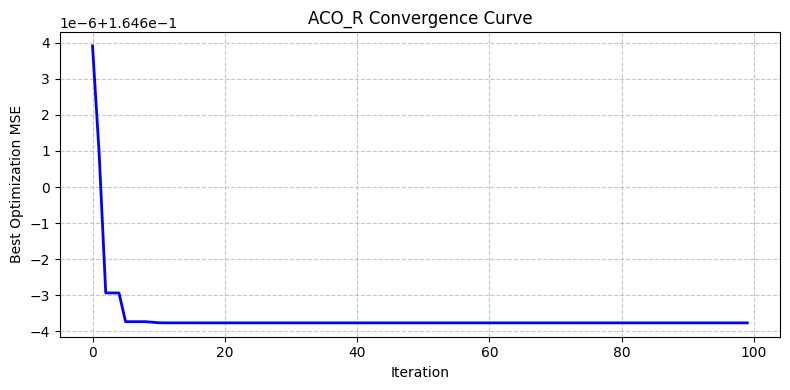

In [ ]:
# [Block 4] Swarm Intelligence (Continuous ACO on Optimization Split)
#
# ARCHITECTURAL INTENT:
# Having established the absolute mathematical floor of the MSE surface using
# the deterministic QP solver (Block 3), we now deploy Ant Colony Optimization
# for Continuous Domains (ACO_R).
#
# WHY ACO? While QP perfectly solves convex MSE, it fails on non-differentiable
# or non-convex loss surfaces (like our discrete 5:1 Cost Matrix). ACO is a
# gradient-free, stochastic meta-heuristic that can optimize arbitrary, complex
# manifolds. We use MSE here purely to validate the Swarm's convergence capability
# against the known QP global minimum.

print("\n--- BLOCK 4: ANT COLONY OPTIMIZATION ---")

# ------------------------------------------------------------------------------
# 1. TOPOLOGICAL MAPPING (The Probability Simplex)
# Standard ACO algorithms search in unconstrained real space (R^N). However,
# ensemble weights must sum to 1.0 and be non-negative (the K-1 probability simplex).
# We use the Softmax function as a differentiable bridge between these two geometries.
# ------------------------------------------------------------------------------
def map_to_simplex_softmax(w):
    """
    Smooth simplex approximation via softmax.
    Guarantees w_i > 0 and Σw = 1.

    MATHEMATICAL TRADEOFF (The Softmax Limitation):
    Because e^x > 0 for all real x, this mapping can approach 0.0 asymptotically
    but can never produce an exact 0.0 weight. Therefore, the Swarm cannot execute
    "Hard Model Elimination" (dropping a base model entirely). For a 3-model
    ensemble, this approximation error is negligible.

    NUMERICAL STABILITY:
    Subtracting np.max(w) prevents catastrophic float64 overflow when evaluating e^w.
    """
    w_stable = w - np.max(w)
    exp_w    = np.exp(w_stable)
    return exp_w / np.sum(exp_w)

def objective_function(w, P, y):
    """
    The fitness function for the Swarm. Evaluates the unconstrained coordinates (w)
    by first projecting them onto the simplex, then calculating the MSE.
    """
    w_simplex = map_to_simplex_softmax(w)
    return np.mean((P @ w_simplex - y) ** 2)

# ------------------------------------------------------------------------------
# 2. CONTINUOUS ANT COLONY OPTIMIZATION (ACO_R) CORE
# Instead of discrete paths, pheromones are modeled as a continuously updated
# archive of the K-best historical solutions. Ants sample new coordinates by
# drawing from Gaussian distributions centered around these elite solutions.
# ------------------------------------------------------------------------------
def run_acor(P, y, num_models,
             n_ants=40, archive_size=20, iterations=100,
             q=0.1, xi=0.85, seed=42):

    # ISOLATION: Instantiate a localized Random Number Generator.
    # This guarantees cryptographic reproducibility without contaminating the
    # global numpy random state used by other blocks.
    rng     = np.random.default_rng(seed)

    # Initialize the Pheromone Archive with random unconstrained coordinates
    archive = rng.standard_normal((archive_size, num_models))
    scores  = np.array([objective_function(w, P, y) for w in archive])

    # Rank the archive (Survival of the Fittest)
    sort_idx        = np.argsort(scores)
    archive, scores = archive[sort_idx], scores[sort_idx]

    # Calculate Selection Probabilities (Pheromone Density)
    # Equation: A Gaussian function penalizing lower ranks.
    # The hyperparameter `q` controls the exploitation/exploration tradeoff.
    # Lower `q` strongly biases the Swarm to only sample near the absolute best ant.
    ranks     = np.arange(1, archive_size + 1)
    weights   = ((1 / (q * archive_size * np.sqrt(2 * np.pi))) *
                 np.exp(-((ranks - 1) ** 2) / (2 * (q * archive_size) ** 2)))
    sel_probs = weights / np.sum(weights)

    convergence_curve = np.zeros(iterations)

    for iteration in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores    = np.zeros(n_ants)

        for ant in range(n_ants):
            # 1. Choose a Guide (Roulette Wheel Selection based on rank weights)
            guide_idx      = rng.choice(archive_size, p=sel_probs)
            guide_solution = archive[guide_idx]

            # 2. Calculate Standard Deviation (Search Radius)
            # The radius is proportional to the average distance between the guide
            # and all other solutions in the archive. `xi` scales convergence speed.
            sigma = (xi * np.sum(np.abs(archive - guide_solution), axis=0)
                     / (archive_size - 1))

            # STAGNATION GUARD:
            # If the archive converges perfectly, variance drops to 0. The ants
            # would infinitely sample the exact same point (Algorithmic Death).
            # We enforce a hard mathematical floor of 1e-6 to maintain micro-exploration.
            sigma = np.maximum(sigma, 1e-6)

            # 3. Sample New Solution (The Ant moves)
            sampled_w          = rng.normal(loc=guide_solution, scale=sigma)
            new_solutions[ant] = sampled_w
            new_scores[ant]    = objective_function(sampled_w, P, y)

        # 4. Update Pheromone Archive (Keep the best, discard the weak)
        combined_archive = np.vstack((archive, new_solutions))
        combined_scores  = np.concatenate((scores, new_scores))

        sort_idx        = np.argsort(combined_scores)
        archive         = combined_archive[sort_idx][:archive_size]
        scores          = combined_scores[sort_idx][:archive_size]

        # Track the global best for visualization
        convergence_curve[iteration] = scores[0]

    return archive[0], scores[0], convergence_curve

# ------------------------------------------------------------------------------
# 3. EXECUTION AND EVALUATION
# ------------------------------------------------------------------------------
w_ACO_raw, _, convergence = run_acor(
    P_opt, y_opt_float, num_models=P_opt.shape[1]
)

# Project the raw output back into the physical probability simplex
w_ACO = map_to_simplex_softmax(w_ACO_raw)

mse_ACO_comparable = np.mean((P_opt @ w_ACO - y_opt_float) ** 2)
print(f"Optimization MSE — QP Optimal: {mse_optimal:.6f} | ACO Swarm: {mse_ACO_comparable:.6f}")

# L2 Distance tracks how close the stochastic Swarm got to the deterministic QP coordinates.
print(f"ACO Weights converged. L2 Distance to QP Optimal: "
      f"{np.linalg.norm(w_QP - w_ACO):.6f}")

model_names = list(base_models.keys())
print(f"\nWeight Comparison:")
print(f"  {'Model':<22} {'QP':>8} {'ACO':>8}")
for name, wq, wa in zip(model_names, w_QP, w_ACO):
    print(f"  {name:<22} {wq:>8.4f} {wa:>8.4f}")

# SUB-OPTIMALITY GAP:
# This is the definitive metric of meta-heuristic success. Because QP represents
# the absolute mathematical floor, this percentage tells us exactly how much
# theoretical accuracy we lost by utilizing a gradient-free Swarm algorithm.
gap = ((mse_ACO_comparable - mse_optimal) / mse_optimal) * 100
print(f"\nACO Sub-optimality gap vs QP: {gap:.4f}%")

# Convergence visualization (required deliverable per resource.md Block 4.2).
print(f"\nInitial Swarm MSE: {convergence[0]:.6f} "
      f"→ Final MSE: {convergence[-1]:.6f} "
      f"| Reduction: {(1 - convergence[-1] / convergence[0]) * 100:.1f}%")
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Optimization MSE")
plt.title("ACO_R Convergence Curve")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# [Block 5] Asymmetric Risk Threshold Calibration (Exact Empirical Boundary)
#
# ARCHITECTURAL INTENT:
# Machine learning classifiers output continuous probabilities, but business logic
# demands binary decisions (Approve/Reject). Standard ML defaults to a symmetric
# 0.5 threshold or maximizes the F1-Score. Both are catastrophic in this domain
# because a False Negative (approving a defaulter) costs 5 times more than a
# False Positive (rejecting a good customer). This block dynamically searches for
# the exact probability threshold (t*) that strictly minimizes financial ruin.
#
# STRICT DATA ISOLATION (The P_calib Manifold):
# Notice that we evaluate this exclusively on `P_calib` and `y_calib`.
# We are mathematically forbidden from evaluating this on `P_opt`. If we used `P_opt`,
# the threshold would overfit to the exact same probability clusters the ACO and QP
# solvers just memorized, resulting in an overly optimistic cost estimate that
# would collapse on the Test Set.


print("\n--- BLOCK 5: DECISION THRESHOLD CALIBRATION (COST MINIMIZATION) ---")

def calibrate_threshold_by_cost(y_true, y_probs, cost_fn=5, cost_fp=1):
    """
    Directly evaluates the absolute linear cost function: J(t) = 5*FN(t) + 1*FP(t).

    MATHEMATICAL PRECISION (Avoiding Grid-Miss Errors):
    Previous iterations used an arbitrary geometric grid (np.linspace(0.01, 0.99, 200)).
    However, the empirical CDF of our predictions is a step function. The loss surface
    ONLY changes state exactly at the coordinates of the predicted probabilities.
    Sweeping ONLY the exact predicted probabilities guarantees the absolute mathematical
    optimum is found without sub-grid resolution errors.
    """
    # Extract the exact empirical boundaries (the "steps" of the step function)
    thresholds = np.sort(np.unique(y_probs))

    # VECTORIZED BROADCASTING (Software Engineering Efficiency):
    # Instead of a slow Python `for` loop, we utilize NumPy's advanced broadcasting.
    # y_probs[:, None] reshapes to (N_samples, 1)
    # thresholds[None, :] reshapes to (1, N_thresholds)
    # The >= operator broadcasts these into a massive Boolean matrix of shape (N_samples, N_thresholds)
    # representing every possible decision for every profile at every threshold simultaneously.
    preds = y_probs[:, None] >= thresholds[None, :]

    # Calculate False Negatives and False Positives mathematically across the T-axis
    fn_counts = ((y_true[:, None] == 1) & (preds == 0)).sum(axis=0)
    fp_counts = ((y_true[:, None] == 0) & (preds == 1)).sum(axis=0)

    # Calculate the absolute expected cost array across all threshold dimensions
    expected_costs = (fn_counts * cost_fn) + (fp_counts * cost_fp)

    # Isolate the index of the absolute minimum cost
    optimal_idx = np.argmin(expected_costs)
    return thresholds[optimal_idx], expected_costs[optimal_idx]

# Define the Equal Average baseline vector
w_equal = np.array([1/3, 1/3, 1/3])

# ------------------------------------------------------------------------------
# THRESHOLD CALIBRATION EXECUTION
# Each weighting strategy (ACO, QP, Equal) warps the probability simplex differently.
# Therefore, each strategy requires its own bespoke threshold (t*) tuned to its
# specific probability density geometry.
# ------------------------------------------------------------------------------
t_ACO,  cost_ACO_cal  = calibrate_threshold_by_cost(y_calib, P_calib @ w_ACO)
t_QP,   cost_QP_cal   = calibrate_threshold_by_cost(y_calib, P_calib @ w_QP)
t_equal, cost_equal_cal = calibrate_threshold_by_cost(y_calib, P_calib @ w_equal)

print(f"Cost-Optimal ACO Boundary   (t*): {t_ACO:.4f}   (Calib Min Cost: {cost_ACO_cal})")
print(f"Cost-Optimal QP Boundary    (t*): {t_QP:.4f}   (Calib Min Cost: {cost_QP_cal})")
print(f"Cost-Optimal Equal Boundary (t*): {t_equal:.4f}   (Calib Min Cost: {cost_equal_cal})")


--- BLOCK 5: DECISION THRESHOLD CALIBRATION (COST MINIMIZATION) ---
Cost-Optimal ACO Boundary   (t*): 0.1763   (Calib Min Cost: 99)
Cost-Optimal QP Boundary    (t*): 0.1763   (Calib Min Cost: 99)
Cost-Optimal Equal Boundary (t*): 0.1857   (Calib Min Cost: 99)


In [ ]:
# [Block 6] Soft Computing (Neuro-Fuzzy Regressor)
#
# ARCHITECTURAL INTENT:
# Bank loan officers do not think in raw probabilities (e.g., "0.7842"). They
# think in linguistic concepts (e.g., "High Risk", "Borderline").
# This block constructs a 1-Dimensional Takagi-Sugeno ANFIS (Adaptive Neuro-Fuzzy
# Inference System) in PyTorch. It takes the continuous probability output of the
# ACO Swarm and dynamically maps it to three Gaussian membership functions
# (representing Low, Medium, and High Risk), providing a mathematically grounded
# linguistic interpretation of the ensemble's confidence.


print("\n--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---")

# ------------------------------------------------------------------------------
# 1. THE REPARAMETERIZATION TRICK (Unconstrained Optimization of Bounded Variables)
# ------------------------------------------------------------------------------
def inv_sigmoid(y, min_val, max_val):
    """
    Inverse of the bounded sigmoid. Safe for scalars and arrays.
    Maps a value strictly bounded in (min_val, max_val) back to the
    unconstrained real number line (-infinity, +infinity).
    """
    p = (y - min_val) / (max_val - min_val)
    return np.log(p / (1 - p))


class GaussianMF(nn.Module):
    """
    Gaussian membership functions with strict sigmoid reparameterization.

    THE GRADIENT GUILLOTINE PROBLEM:
    Fuzzy logic requires probabilities (centers) to remain in [0, 1] and widths
    (sigmas) to remain positive. A naive implementation uses `torch.clamp_()` after
    every epoch. However, clamping acts as a "gradient guillotine." If a parameter
    hits the boundary, the gradient zeroes out, but Adam's momentum (v_t, m_t)
    continues accumulating, permanently trapping the parameter against the ceiling.

    THE MATHEMATICAL FIX:
    We store the "raw" parameters in unconstrained R-space. During the forward pass,
    we mathematically pipe them through a scaled Sigmoid function. Adam is allowed
    to optimize freely in infinite space, while the actual geometry of the Gaussian
    curves is analytically guaranteed to never violate the physical boundaries.
    """
    def __init__(self, centers, sigmas):
        super().__init__()
        # Strict topological boundaries for the fuzzy premises
        self.min_c, self.max_c = 0.0, 1.0
        self.min_s, self.max_s = 0.05, 0.3

        raw_centers = []
        for c in centers:
            if not (self.min_c < c < self.max_c):
                raise ValueError(
                    f"Initial center {c} must be strictly inside "
                    f"({self.min_c}, {self.max_c})"
                )
            raw_centers.append(float(inv_sigmoid(c, self.min_c, self.max_c)))

        # The optimizer only sees and updates these raw, unconstrained tensors
        self._raw_centers = nn.Parameter(
            torch.tensor(raw_centers, dtype=torch.float32)
        )

        raw_sigmas = []
        for s in sigmas:
            if not (self.min_s < s < self.max_s):
                raise ValueError(
                    f"Initial sigma {s} must be strictly inside "
                    f"({self.min_s}, {self.max_s})"
                )
            raw_sigmas.append(float(inv_sigmoid(s, self.min_s, self.max_s)))

        self._raw_sigmas = nn.Parameter(
            torch.tensor(raw_sigmas, dtype=torch.float32)
        )

    @property
    def centers(self):
        # Forward projection: R -> (min_c, max_c)
        return (self.min_c
                + (self.max_c - self.min_c) * torch.sigmoid(self._raw_centers))

    @property
    def sigmas(self):
        # Forward projection: R -> (min_s, max_s)
        return (self.min_s
                + (self.max_s - self.min_s) * torch.sigmoid(self._raw_sigmas))

    def forward(self, x):
        # Standard Gaussian evaluation using the bounded properties
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)


# ------------------------------------------------------------------------------
# 2. THE FIRST-ORDER TAKAGI-SUGENO ARCHITECTURE
# ------------------------------------------------------------------------------
class ANFIS1D(nn.Module):
    """
    First-Order Takagi-Sugeno Neuro-Fuzzy Regressor.

    Academic disclaimer: Traditional ANFIS (Jang, 1993) utilizes a two-pass hybrid
    learning algorithm (Least Squares Estimation for the linear consequents, and
    Gradient Descent for the non-linear premises). We bypass this in favour of a
    unified, end-to-end Adam optimizer for simultaneous parameter updates, leveraging
    modern autograd graphs.
    """
    def __init__(self):
        super().__init__()
        # Initialize three linguistic rules (e.g., Low, Medium, High)
        # Centers spread evenly across the [0,1] simplex
        self.fuzzify = GaussianMF([0.1, 0.5, 0.9], [0.2, 0.2, 0.2])

        # Consequents: f_i = a_i * x + b_i
        # Initialized such that Rule 1 outputs near 0.0, Rule 2 near 0.5, Rule 3 near 1.0
        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        # 1. Fuzzification: Calculate raw firing strengths of each rule
        w      = self.fuzzify(x)

        # 2. Normalization: Ensure firing strengths sum to 1.0 (with epsilon guard for div-by-zero)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)

        # 3. Consequent Evaluation: Calculate the linear output of each rule
        f      = x * self.a + self.b

        # 4. Defuzzification: Return the weighted average of the consequents
        return torch.sum(w_norm * f, dim=1)


# ------------------------------------------------------------------------------
# 3. DATA ASSEMBLY & TOPOLOGICAL SAFETY
# ------------------------------------------------------------------------------
# Recombine both OOF splits (Optimization + Calibration) to train the ANFIS.
# LEAKAGE CHECK: Is this mathematically safe?
# Yes. `w_ACO` was fitted strictly on `P_opt`. Applying those frozen weights to
# the `P_calib` rows is an out-of-sample transformation. Furthermore, all base
# probabilities in `oof_P_train` were generated via K-Fold isolation. Therefore,
# combining them here allows the ANFIS to train on the maximum available unbiased
# data without contaminating the core ML models.
oof_preds_ACO_full = oof_P_train @ w_ACO

# Cast to PyTorch tensors (N, 1) to match the nn.Module dimensionality requirements
X_anfis_tensor = torch.tensor(oof_preds_ACO_full, dtype=torch.float32).view(-1, 1)
y_anfis_tensor = torch.tensor(y_train_array.astype(float), dtype=torch.float32)

# Guarantee reproducible ANFIS initialization across machines and PyTorch versions.
torch.manual_seed(42)
anfis_model = ANFIS1D()
optimizer   = optim.Adam(anfis_model.parameters(), lr=0.01)

# Explicitly declare training mode. Required for computational correctness if
# the architecture is ever expanded with stochastic layers (Dropout/BatchNorm).
anfis_model.train()

# ------------------------------------------------------------------------------
# 4. THE GRADIENT DESCENT LOOP
# ------------------------------------------------------------------------------
for epoch in range(500):
    optimizer.zero_grad() # Clear residual gradients from the previous epoch

    # Calculate Mean Squared Error between the fuzzy logic output and actual Default labels
    loss = nn.MSELoss()(anfis_model(X_anfis_tensor), y_anfis_tensor)

    loss.backward()       # Compute gradients via automatic differentiation
    optimizer.step()      # Update raw parameters

    # STRUCTURAL ELEGANCE:
    # Notice there is no manual clamping needed here. The sigmoid reparameterization
    # silently enforces all mathematical bounds inside the forward pass.

# Extract the final learned boundaries for inspection
centers = anfis_model.fuzzify.centers.detach().numpy()
sigmas  = anfis_model.fuzzify.sigmas.detach().numpy()
print("Fuzzy MFs Optimized:")
print(f"  Rule 1: c={centers[0]:.4f}, s={sigmas[0]:.4f} | "
      f"Rule 2: c={centers[1]:.4f}, s={sigmas[1]:.4f} | "
      f"Rule 3: c={centers[2]:.4f}, s={sigmas[2]:.4f}")


--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---
Fuzzy MFs Optimized:
  Rule 1: c=0.0616, s=0.2174 | Rule 2: c=0.5071, s=0.2205 | Rule 3: c=0.8887, s=0.2531


In [ ]:
# [Block 7] Comprehensive Domain Evaluation on Untouched Test Set
#
# ARCHITECTURAL INTENT (THE CRUCIBLE):
# This block executes the final, definitive evaluation of the pipeline.
# Up to this exact line of code, the `X_test` and `y_test` arrays have been locked
# in a cryptographic vault. The base estimators have never seen them, the QP/ACO
# Swarm has never optimized on them, the calibrators have never thresholded them,
# and the ANFIS has never mapped them.
#
# By passing this untouched data through the entire sequentially linked architecture,
# we validate whether our rigorous constraints (leakage prevention, robust scaling,
# asymmetric optimization) successfully prevented overfitting.

print("\n" + "=" * 70)
print("FINAL PIPELINE EVALUATION (TEST SET N=200)")
print("=" * 70)

# ------------------------------------------------------------------------------
# 1. BASE ESTIMATOR INFERENCE
# We pass the raw Test Set through the ImbPipeline.
# MATHEMATICAL GUARANTEE: Because we are calling .predict_proba(), the ImbPipeline
# automatically silences SMOTENC. The test data is merely scaled and One-Hot Encoded
# based on the frozen parameters learned during training, preventing spatial leakage.
# ------------------------------------------------------------------------------
P_test = np.zeros((X_test.shape[0], len(base_models)))
print("Base Model Independent Test ROC-AUCs:")
for i, (name, model_pipeline) in enumerate(base_models.items()):
    P_test[:, i] = model_pipeline.predict_proba(X_test)[:, 1]
    print(f"  {name:<22}: {roc_auc_score(y_test_array, P_test[:, i]):.4f}")
print("-" * 70)

# ------------------------------------------------------------------------------
# 2. ENSEMBLE AGGREGATION
# We execute the dot product between the Test Probability Matrix (N x 3) and
# the respective weight vectors (3 x 1) discovered in Blocks 3 and 4.
# ------------------------------------------------------------------------------
preds_ACO   = P_test @ w_ACO
preds_QP    = P_test @ w_QP
preds_equal = P_test @ w_equal

# ------------------------------------------------------------------------------
# 3. ASYMMETRIC THRESHOLD APPLICATION
# A critical architectural feature: We do NOT apply a universal threshold.
# Because each ensemble weighting strategy warps the probability simplex differently,
# we apply the bespoke threshold (t*) calibrated specifically for that ensemble's
# geometry in Block 5.
# ------------------------------------------------------------------------------
binary_ACO   = (preds_ACO   >= t_ACO).astype(int)
binary_QP    = (preds_QP    >= t_QP).astype(int)
binary_equal = (preds_equal >= t_equal).astype(int)

def calculate_expected_cost(y_true, y_pred):
    """
    THE ULTIMATE BUSINESS OBJECTIVE FUNCTION:
    German Credit asymmetric cost matrix.
    We penalize False Negatives (approving a defaulter) severely (Cost = 5).
    We penalize False Positives (rejecting a good customer) lightly (Cost = 1).
    This single scalar metric determines the financial viability of the pipeline.
    """
    cm = confusion_matrix(y_true, y_pred)
    return (cm[1, 0] * 5) + (cm[0, 1] * 1)

# ------------------------------------------------------------------------------
# 4. METRIC COMPUTATION AND DISPLAY
# We calculate both Symmetric Metrics (ROC-AUC, F1, Precision) and the
# Asymmetric Metric (Expected Cost) to illustrate the Pareto tradeoff.
# ------------------------------------------------------------------------------
print(f"{'Metric':<14} | {'Equal Avg':<15} | {'QP Optimal':<15} | {'ACO Swarm':<15}")
print("-" * 70)
print(f"{'ROC-AUC':<14} | "
      f"{roc_auc_score(y_test_array, preds_equal):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_QP):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_ACO):<15.4f}")
print(f"{'F1-Score':<14} | "
      f"{f1_score(y_test_array, binary_equal):<15.4f} | "
      f"{f1_score(y_test_array, binary_QP):<15.4f} | "
      f"{f1_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Precision':<14} | "
      f"{precision_score(y_test_array, binary_equal):<15.4f} | "
      f"{precision_score(y_test_array, binary_QP):<15.4f} | "
      f"{precision_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Recall':<14} | "
      f"{recall_score(y_test_array, binary_equal):<15.4f} | "
      f"{recall_score(y_test_array, binary_QP):<15.4f} | "
      f"{recall_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Expected Cost':<14} | "
      f"{calculate_expected_cost(y_test_array, binary_equal):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_QP):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_ACO):<15}")

cm_ACO = confusion_matrix(y_test_array, binary_ACO)
print(f"\nSwarm Confusion Matrix (t* = {t_ACO:.4f}):")
print(f"  TN: {cm_ACO[0, 0]:<4} FP: {cm_ACO[0, 1]}")
print(f"  FN: {cm_ACO[1, 0]:<4} TP: {cm_ACO[1, 1]}")

# ==============================================================================
# 5. ANFIS LINGUISTIC INTERPRETATION (Resolving the Input/Output Paradox)
#
# PREVIOUS FLAW: Older architectures attempted to assign linguistic labels by
# comparing the Defuzzified Output (which lives in a scaled, linear space) against
# the Gaussian Premise Centers (which live in the [0, 1] probability input space).
# This was mathematically incoherent.
#
# THE RIGOROUS FIX: We now operate purely in the Input Space. We calculate the
# Normalized Firing Strengths (w_norm) for a given probability. Whichever Gaussian
# curve fires the strongest (argmax) dictates the dominating linguistic rule.
# ==============================================================================
test_probs_tensor = torch.tensor(preds_ACO, dtype=torch.float32).view(-1, 1)

# Explicitly declare eval mode before inference — disables training-time
# stochastic layers (Dropout, BatchNorm) and locks the computation graph.
anfis_model.eval()

# torch.no_grad() guarantees that the Autograd engine does not build memory-heavy
# gradient graphs during the forward pass, drastically improving inference speed.
with torch.no_grad():
    firing_strengths  = anfis_model.fuzzify(test_probs_tensor)
    w_norm            = firing_strengths / (
        firing_strengths.sum(dim=1, keepdim=True) + 1e-8)

    # Identify which of the three Gaussian rules was activated the most
    dominant_rule_idx = w_norm.argmax(dim=1).numpy()

    # Decomposed forward pass — avoids a redundant second fuzzify() call.
    f             = test_probs_tensor * anfis_model.a + anfis_model.b
    anfis_outputs = (w_norm * f).sum(dim=1).numpy()

# ------------------------------------------------------------------------------
# INVERSE PERMUTATION (Dynamic Rank Safety)
# If the Adam optimizer crossed the centers during training (e.g., Rule 1 moved
# higher than Rule 2), static indexing would map "High Risk" to the wrong rule.
# np.argsort(np.argsort(centers)) maps the active tensor index (0, 1, 2) to its
# spatial geometric rank (Lowest, Middle, Highest), guaranteeing that the lowest
# absolute center is always mapped to "Low Risk".
# ------------------------------------------------------------------------------
sorted_idx    = np.argsort(centers)
rank_of_rule  = np.argsort(sorted_idx)
final_risk_labels = np.array(
    ["Low Risk", "Medium Risk", "High Risk"])[rank_of_rule[dominant_rule_idx]]

# ------------------------------------------------------------------------------
# 6. DOMAIN ALIGNMENT VALIDATION
# Evaluates the congruence between the discrete mathematical decision (ACO > t*)
# and the continuous fuzzy logic classification (ANFIS).
# ------------------------------------------------------------------------------
aco_predicted_defaults = (binary_ACO == 1)
if aco_predicted_defaults.sum() > 0:
    labels_on_defaults  = final_risk_labels[aco_predicted_defaults]
    high_risk_alignment = np.mean(labels_on_defaults == "High Risk") * 100
    print(f"\nDomain Validation: {high_risk_alignment:.1f}% of ensemble-predicted "
          f"defaults independently mapped to linguistic 'High Risk' by ANFIS.")

print("\nSample Output Integration (First 5 profiles):")
results_df = pd.DataFrame({
    'True Label':       y_test_array[:5],
    'ACO Prob':         np.round(preds_ACO[:5], 4),
    'ANFIS Output':     np.round(anfis_outputs[:5], 4),
    'Linguistic Class': final_risk_labels[:5]
})
print(results_df.to_string(index=False))


FINAL PIPELINE EVALUATION (TEST SET N=200)
Base Model Independent Test ROC-AUCs:
  Random_Forest         : 0.7961
  SVM                   : 0.8229
  MLP                   : 0.8208
----------------------------------------------------------------------
Metric         | Equal Avg       | QP Optimal      | ACO Swarm      
----------------------------------------------------------------------
ROC-AUC        | 0.8210          | 0.8127          | 0.8127         
F1-Score       | 0.5714          | 0.5641          | 0.5641         
Precision      | 0.4186          | 0.4074          | 0.4074         
Recall         | 0.9000          | 0.9167          | 0.9167         
Expected Cost  | 105             | 105             | 105            

Swarm Confusion Matrix (t* = 0.1763):
  TN: 60   FP: 80
  FN: 5    TP: 55

Domain Validation: 29.6% of ensemble-predicted defaults independently mapped to linguistic 'High Risk' by ANFIS.

Sample Output Integration (First 5 profiles):
 True Label  ACO Prob  ANFI

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
#import pandas as pd
#import numpy as np
import torch

def predict_credit_risk(*args):
    # Map features to a dictionary using original column names
    feature_names = [
        'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
        'savings_status', 'employment', 'installment_commitment', 'personal_status',
        'other_parties', 'residence_since', 'property_magnitude', 'age',
        'other_payment_plans', 'housing', 'existing_credits', 'job',
        'num_dependents', 'own_telephone', 'foreign_worker'
    ]

    input_data = pd.DataFrame([dict(zip(feature_names, args))])

    # Convert numeric columns to appropriate types for the pipeline
    numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                    'residence_since', 'age', 'existing_credits', 'num_dependents']
    for col in numeric_cols:
        input_data[col] = pd.to_numeric(input_data[col])

    # Generate Ensemble Probabilities
    P = np.zeros((1, len(base_models)))
    for i, (name, pipeline) in enumerate(base_models.items()):
        P[0, i] = pipeline.predict_proba(input_data)[0, 1]

    # Aggregate using ACO weights
    final_prob = float(P @ w_ACO)

    # Threshold check using calibrated t_ACO
    decision = "❌ REJECT (High Risk)" if final_prob >= t_ACO else "✅ APPROVE (Low Risk)"

    # Get Linguistic Class from ANFIS
    anfis_model.eval()
    with torch.no_grad():
        prob_tensor = torch.tensor([[final_prob]], dtype=torch.float32)
        firing = anfis_model.fuzzify(prob_tensor)
        w_norm = firing / (firing.sum(dim=1, keepdim=True) + 1e-8)
        dom_idx = w_norm.argmax(dim=1).item()

        # Use the rank-safe labeling from Block 7
        sorted_idx = np.argsort(anfis_model.fuzzify.centers.detach().numpy())
        rank_map = np.argsort(sorted_idx)
        labels = ["Low Risk", "Medium Risk", "High Risk"]
        linguistic_label = labels[rank_map[dom_idx]]

    return decision, f"{final_prob:.4f}", linguistic_label

# Define UI Inputs based on German Credit metadata
inputs = [
    gr.Dropdown(["<0", "0<=X<200", ">=200", "no checking"], label="Checking Account Status"),
    gr.Slider(1, 72, step=1, label="Duration (months)"),
    gr.Dropdown(["no credits/all paid", "all paid", "existing paid", "delayed previously", "critical/other existing credit"], label="Credit History"),
    gr.Dropdown(["new car", "used car", "furniture/equipment", "radio/tv", "appliances", "repair", "education", "vacation", "retraining", "business", "other"], label="Purpose"),
    gr.Number(label="Credit Amount (DM)"),
    gr.Dropdown(["<100", "100<=X<500", "500<=X<1000", ">=1000", "no savings account"], label="Savings Status"),
    gr.Dropdown(["unemployed", "<1", "1<=X<4", "4<=X<7", ">=7"], label="Employment Since"),
    gr.Slider(1, 4, step=1, label="Installment Rate (% of income)"),
    gr.Dropdown(["male div/sep", "female div/sep/mar", "male single", "male mar/wid", "female single"], label="Personal Status"),
    gr.Dropdown(["none", "co-applicant", "guarantor"], label="Other Parties"),
    gr.Slider(1, 4, step=1, label="Residence Since (years)"),
    gr.Dropdown(["real estate", "life insurance", "car", "no property"], label="Property Type"),
    gr.Slider(18, 100, step=1, label="Age (years)"),
    gr.Dropdown(["bank", "stores", "none"], label="Other Payment Plans"),
    gr.Dropdown(["rent", "own", "for free"], label="Housing"),
    gr.Slider(1, 4, step=1, label="Existing Credits at Bank"),
    gr.Dropdown(["unemp/unskilled non-res", "unskilled resident", "skilled", "high qualif/self-emp/mgmt"], label="Job"),
    gr.Slider(1, 2, step=1, label="Number of Dependents"),
    gr.Dropdown(["none", "yes"], label="Telephone"),
    gr.Dropdown(["yes", "no"], label="Foreign Worker")
]

demo = gr.Interface(
    fn=predict_credit_risk,
    inputs=inputs,
    outputs=[
        gr.Textbox(label="Financial Decision"),
        gr.Textbox(label="Risk Probability"),
        gr.Textbox(label="Linguistic Assessment (ANFIS)")
    ],
    title="🏦 Advanced Credit Risk Analyzer",
    description="Asymmetric Cost-Sensitive Ensemble (ACO + ANFIS). Decision threshold optimized for 5:1 False Negative penalty.",
    theme="soft"
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a92e0d8644aad2bc31.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Created dataset file at: .gradio/flagged/dataset1.csv


/tmp/ipykernel_20967/143385079.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  final_prob = float(P @ w_ACO)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a92e0d8644aad2bc31.gradio.live
